<a href="https://colab.research.google.com/github/weathon/neg/blob/main/NAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/ChenDarYen/Normalized-Attention-Guidance.git

fatal: destination path 'Normalized-Attention-Guidance' already exists and is not an empty directory.


In [2]:
!pip install image-reward clip -qq

In [3]:
!pip install -r Normalized-Attention-Guidance/requirements.txt -qq

In [4]:
import sys
sys.path.append("Normalized-Attention-Guidance")

In [5]:
from huggingface_hub import login

In [6]:
import ImageReward as reward
reward_model = reward.load("ImageReward-v1.0")

load checkpoint from /root/.cache/ImageReward/ImageReward.pt
checkpoint loaded


In [7]:
import math
from typing import Optional

import torch
import torch.nn.functional as F

from diffusers.models.attention_processor import Attention
from diffusers.models.embeddings import apply_rotary_emb
import pylab
import random

class NAGFluxAttnProcessor2_0:
    """Attention processor used typically in processing the SD3-like self-attention projections."""

    def __init__(
            self,
            nag_scale: float = 1.0,
            nag_tau=2.5,
            nag_alpha=0.25,
            encoder_hidden_states_length: int = None,
            pos_prompt_length: int = None,
            neg_prompt_length: int = None,
    ):
        if not hasattr(F, "scaled_dot_product_attention"):
            raise ImportError("FluxAttnProcessor2_0 requires PyTorch 2.0, to use it, please upgrade PyTorch to 2.0.")
        self.nag_scale = nag_scale
        self.nag_tau = nag_tau
        self.nag_alpha = nag_alpha
        self.encoder_hidden_states_length = encoder_hidden_states_length
        self.pos_prompt_length = pos_prompt_length
        self.neg_prompt_length = neg_prompt_length

    def __call__(
        self,
        attn: Attention,
        hidden_states: torch.FloatTensor,
        encoder_hidden_states: torch.FloatTensor = None,
        attention_mask: Optional[torch.FloatTensor] = None,
        image_rotary_emb: Optional[torch.Tensor] = None,
    ) -> torch.FloatTensor:
        batch_size, _, _ = hidden_states.shape if encoder_hidden_states is None else encoder_hidden_states.shape
        # print(hidden_states.shape)
        if self.nag_scale > 1.:
            if encoder_hidden_states is not None:
                assert len(hidden_states) == batch_size * 0.5
            apply_guidance = True
        else:
            apply_guidance = False

        # `sample` projections.
        query = attn.to_q(hidden_states)
        key = attn.to_k(hidden_states)
        value = attn.to_v(hidden_states)

        # attention
        if apply_guidance and encoder_hidden_states is not None:
            query = query.tile(2, 1, 1)
            key = key.tile(2, 1, 1)
            value = value.tile(2, 1, 1)

        inner_dim = key.shape[-1]
        head_dim = inner_dim // attn.heads

        query = query.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)
        key = key.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)
        value = value.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)

        if attn.norm_q is not None:
            query = attn.norm_q(query)
        if attn.norm_k is not None:
            key = attn.norm_k(key)

        # the attention in FluxSingleTransformerBlock does not use `encoder_hidden_states`
        if encoder_hidden_states is not None:
            # `context` projections.
            encoder_hidden_states_query_proj = attn.add_q_proj(encoder_hidden_states)
            encoder_hidden_states_key_proj = attn.add_k_proj(encoder_hidden_states)
            encoder_hidden_states_value_proj = attn.add_v_proj(encoder_hidden_states)

            encoder_hidden_states_query_proj = encoder_hidden_states_query_proj.view(
                batch_size, -1, attn.heads, head_dim
            ).transpose(1, 2)
            encoder_hidden_states_key_proj = encoder_hidden_states_key_proj.view(
                batch_size, -1, attn.heads, head_dim
            ).transpose(1, 2)
            encoder_hidden_states_value_proj = encoder_hidden_states_value_proj.view(
                batch_size, -1, attn.heads, head_dim
            ).transpose(1, 2)

            if attn.norm_added_q is not None:
                encoder_hidden_states_query_proj = attn.norm_added_q(encoder_hidden_states_query_proj)
            if attn.norm_added_k is not None:
                encoder_hidden_states_key_proj = attn.norm_added_k(encoder_hidden_states_key_proj)

            query = torch.cat([encoder_hidden_states_query_proj, query], dim=2)
            key = torch.cat([encoder_hidden_states_key_proj, key], dim=2)
            value = torch.cat([encoder_hidden_states_value_proj, value], dim=2)

            encoder_hidden_states_length = encoder_hidden_states.shape[1]

        else:
            assert self.encoder_hidden_states_length is not None
            encoder_hidden_states_length = self.encoder_hidden_states_length

        if image_rotary_emb is not None:
            query = apply_rotary_emb(query, image_rotary_emb)
            key = apply_rotary_emb(key, image_rotary_emb)

        if not apply_guidance:
            hidden_states = F.scaled_dot_product_attention(query, key, value, dropout_p=0.0, is_causal=False)
            hidden_states = hidden_states.transpose(1, 2).reshape(batch_size, -1, attn.heads * head_dim)
            hidden_states = hidden_states.to(query.dtype)

        else:
            origin_batch_size = batch_size // 2
            query, query_negative = torch.chunk(query, 2, dim=0)
            key, key_negative = torch.chunk(key, 2, dim=0)
            value, value_negative = torch.chunk(value, 2, dim=0)
            attn_mask = None
            if encoder_hidden_states is not None:
              encoder_neg_query = query_negative[:,:,:encoder_hidden_states_length]
              encoder_neg_key = key_negative[:,:,:encoder_hidden_states_length]
              encoder_neg_value = value_negative[:,:,:encoder_hidden_states_length]
              query_pos_neg = torch.cat([encoder_neg_query, query], dim=2)
              key_pos_neg = torch.cat([encoder_neg_key, key], dim=2)
              # value_pos_neg = torch.cat([-encoder_neg_value, value], dim=2)
              scale = 1 #(self.pos_prompt_length / self.neg_prompt_length) * 0.1
              # print(scale)
              value_pos_neg = torch.cat([encoder_neg_value, value], dim=2)
              l = encoder_hidden_states_length
              value_pos_neg[:,:,:l] *= - scale
              # here we increased the pos scale we need to scale back the value but hows
              attn_mask = torch.zeros((query_pos_neg.shape[0], query_pos_neg.shape[-2], value_pos_neg.shape[-2])).cuda().bfloat16()
              # mask between positive and negative prompts, should not update negative at all because it is negative do
              attn_mask[:,0:l,l:l*2] = -torch.inf
              attn_mask[:,0:l,:] = -torch.inf
              attn_mask[:,l:l*2,0:l] = -torch.inf
              # attn_mask[:,:,self.neg_prompt_length:l] = -torch.inf
              # attn_mask[:,self.neg_prompt_length:l,:] = -torch.inf
              # attn_mask[:,self.pos_prompt_length+l:l*2,:] = -torch.inf
              # attn_mask[:,:,self.pos_prompt_length+l:l*2] = -torch.inf
              # print(l)
              # pylab.imshow(attn_mask[0,:200,:200].cpu().float().detach())
              # pylab.show()
              # 5/0

              hidden_states_regular = F.scaled_dot_product_attention(query, key, value, dropout_p=0.0, is_causal=False)
              hidden_states_regular = hidden_states_regular.transpose(1, 2).reshape(origin_batch_size, -1, attn.heads * head_dim)
              hidden_states_regular = hidden_states_regular.to(query.dtype)

              hidden_state_pure_negative = F.scaled_dot_product_attention(query_negative, key_negative, value_negative, dropout_p=0.0, is_causal=False)
              hidden_state_pure_negative = hidden_state_pure_negative.transpose(1, 2).reshape(origin_batch_size, -1, attn.heads * head_dim)
              hidden_state_pure_negative = hidden_state_pure_negative.to(query.dtype)

            else:
              query_pos_neg, key_pos_neg, value_pos_neg = query, key, value
              hidden_state_pure_negative = F.scaled_dot_product_attention(query_negative, key_negative, value_negative, dropout_p=0.0, is_causal=False)
              hidden_state_pure_negative = hidden_state_pure_negative.transpose(1, 2).reshape(origin_batch_size, -1, attn.heads * head_dim)
              hidden_state_pure_negative = hidden_state_pure_negative.to(query.dtype)

            # do not minus pure negative but still a mix?


            hidden_states = F.scaled_dot_product_attention(query_pos_neg, key_pos_neg, value_pos_neg, dropout_p=0.0, is_causal=False, attn_mask=attn_mask)
            hidden_states = hidden_states.transpose(1, 2).reshape(origin_batch_size, -1, attn.heads * head_dim)
            hidden_states = hidden_states.to(query.dtype)


            if encoder_hidden_states is not None:
              # hidden_states[:,encoder_hidden_states_length:2*encoder_hidden_states_length] -= hidden_states[:,:encoder_hidden_states_length]
              hidden_states = hidden_states[:,encoder_hidden_states_length:]
              assert hidden_states_regular.shape == hidden_states.shape == hidden_state_pure_negative.shape

        if encoder_hidden_states is not None:
            encoder_hidden_states, hidden_states = (
                hidden_states[:, : encoder_hidden_states.shape[1]],
                hidden_states[:, encoder_hidden_states.shape[1] :],
            )

            if apply_guidance:
                encoder_hidden_states_regular, hidden_states_regular = (
                    hidden_states_regular[:, : encoder_hidden_states.shape[1]],
                    hidden_states_regular[:, encoder_hidden_states.shape[1]:],
                )

                encoder_hidden_state_pure_negative, hidden_state_pure_negative = (
                    hidden_state_pure_negative[:, : encoder_hidden_states.shape[1]],
                    hidden_state_pure_negative[:, encoder_hidden_states.shape[1]:],
                )

                # print(mask.mean(), mask.max(), mask.min())
                # hidden_states = hidden_states * self.nag_scale - hidden_state_pure_negative * (self.nag_scale - 1)

                # norm_positive = torch.norm(hidden_states_regular, p=1, dim=-1, keepdim=True).expand(*hidden_states_regular.shape)
                # norm_guidance = torch.norm(hidden_states, p=1, dim=-1, keepdim=True).expand(*hidden_states_regular.shape)

                # scale = norm_guidance / norm_positive
                # hidden_states = hidden_states * torch.minimum(scale, scale.new_ones(1) * self.nag_tau) / scale

                # hidden_states = hidden_states * self.nag_alpha + hidden_states_regular * (1 - self.nag_alpha)
                # hidden_states_strong = hidden_states * 0.5 + hidden_states_regular * (1 - 0.5)
                # hidden_states = torch.where(mask.unsqueeze(-1) > 20, hidden_states_strong, hidden_states_)

                # mix with already-negatived instead of positive
                # hidden_states_guidance = hidden_states * self.nag_scale - hidden_states_regular * (self.nag_scale - 1)

                hidden_states_guidance = hidden_states * self.nag_scale - hidden_state_pure_negative * (self.nag_scale - 1)
                hidden_states_regular_guidence = hidden_states_regular * 2 - hidden_state_pure_negative * (2 - 1)

                norm_positive = torch.norm(hidden_states_regular, p=1, dim=-1, keepdim=True).expand(*hidden_states_regular.shape)
                norm_guidance = torch.norm(hidden_states_guidance, p=1, dim=-1, keepdim=True).expand(*hidden_states_regular.shape)
                scale = norm_guidance / norm_positive
                hidden_states_guidance = hidden_states_guidance * torch.minimum(scale, scale.new_ones(1) * self.nag_tau) / scale

                norm_positive_regular_guidance = torch.norm(hidden_states_regular_guidence, p=1, dim=-1, keepdim=True).expand(*hidden_states_regular_guidence.shape)
                scale = norm_positive_regular_guidance / norm_positive
                hidden_states_regular_guidence = hidden_states_regular_guidence * torch.minimum(scale, scale.new_ones(1)) / scale


                # hidden_states = hidden_states_guidance * self.nag_alpha + hidden_states_regular_guidence * (1 - self.nag_alpha)# * 0.7 + hidden_states_regular * (1 - self.nag_alpha) * 0.3
                hidden_states = hidden_states_guidance * self.nag_alpha + hidden_states_regular * (1 - self.nag_alpha)

                encoder_hidden_states = torch.cat((encoder_hidden_states, encoder_hidden_state_pure_negative), dim=0)
                # encoder_hidden_states = torch.cat((encoder_hidden_states, encoder_hidden_states_regular), dim=0)

            hidden_states = attn.to_out[0](hidden_states)
            hidden_states = attn.to_out[1](hidden_states)

            encoder_hidden_states = attn.to_add_out(encoder_hidden_states)
            # print(hidden_states.shape, encoder_hidden_states.shape)
            return hidden_states, encoder_hidden_states

        else:
            if apply_guidance:
                image_hidden_state_pure_negative = hidden_state_pure_negative[:, encoder_hidden_states_length:]
                image_hidden_states = hidden_states[:, encoder_hidden_states_length:]

                image_hidden_states_guidance = image_hidden_states * self.nag_scale - image_hidden_state_pure_negative * (self.nag_scale - 1)
                norm_positive = torch.norm(image_hidden_states, p=1, dim=-1, keepdim=True).expand(*image_hidden_states.shape)
                norm_guidance = torch.norm(image_hidden_states_guidance, p=1, dim=-1, keepdim=True).expand(*image_hidden_states.shape)

                scale = norm_guidance / norm_positive
                image_hidden_states_guidance = image_hidden_states_guidance * torch.minimum(scale, scale.new_ones(1) * self.nag_tau) / scale
                # scale = torch.nan_to_num(scale, 10)
                # image_hidden_states_guidance[scale > self.nag_tau] = image_hidden_states_guidance[scale > self.nag_tau] / (norm_guidance[scale > self.nag_tau] + 1e-7) * norm_positive[scale > self.nag_tau] * self.nag_tau

                image_hidden_states = image_hidden_states_guidance * self.nag_alpha + image_hidden_states * (1 - self.nag_alpha)

                hidden_state_pure_negative[:, encoder_hidden_states_length:] = image_hidden_states
                hidden_states[:, encoder_hidden_states_length:] = image_hidden_states
                hidden_states = torch.cat((hidden_states, hidden_state_pure_negative), dim=0)
            return hidden_states

In [8]:
import torch
from src.pipeline_flux_nag import NAGFluxPipeline
from src.transformer_flux import NAGFluxTransformer2DModel
from src.attention_flux_nag import NAGFluxAttnProcessor2_0 as NAGFluxAttnProcessor2_0_vanilla

transformer = NAGFluxTransformer2DModel.from_pretrained(
    "black-forest-labs/FLUX.1-schnell",
    subfolder="transformer",
    torch_dtype=torch.bfloat16,
)

if not "pipe" in locals():
  pipe = NAGFluxPipeline.from_pretrained(
      "black-forest-labs/FLUX.1-schnell",
      transformer=transformer,
      torch_dtype=torch.bfloat16,
  )
  pipe.to("cuda")

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [9]:
# prompts = [
#     {
#         "pos": "A surreal cityscape at dusk, where buildings are made of tangled roots and glowing crystals, and the sky is a swirling vortex of deep purples and emerald greens. In the foreground, a lone figure with bioluminescent wings gazes up at a colossal, levitating jellyfish-like creature that casts intricate shadows across the urban flora.",
#         "neg": ""
#     },
#     {
#         "pos": "A clock that blends in with the wall hangs in a bathroom.",
#         "neg": ""
#     },
#     {
#         "pos": "A futuristic library where books are holographic projections and the shelves are intricate, glowing energy conduits. A robot librarian with multiple, articulated arms is delicately placing a shimmering data-orb onto a shelf, while in the background, a group of alien scholars with various forms and colors are engrossed in their studies, illuminated by the soft light of the holographic texts.",
#         "neg": ""
#     }
#     # {
#     #     "pos": "a bathroom in a house",
#     #     "neg": "modern"
#     # },
#     # {
#     #     "pos": "a house in winter",
#     #     "neg": "snow"
#     # },
#     # {
#     #     "pos": "a living room in a house",
#     #     "neg": "clean"
#     # },
#     # {
#     #     "pos": "a house made from wood",
#     #     "neg": "windows"
#     # },
#     # {
#     #     "pos": "a cup of soda in a container",
#     #     "neg": "round cup"
#     # },
#     # {
#     #     "pos": "a cup of soda in a container",
#     #     "neg": "straw"
#     # },
#     # {
#     #     "pos": "a wireless earphone on the table",
#     #     "neg": "plastic"
#     # },
#     # {
#     #     "pos": "a pair of shoes on the ground",
#     #     "neg": "fabric"
#     # },
#     # {
#     #   "pos": "a human standing in the office with a suit",
#     #   "neg": "a tie"
#     # },
#     # {
#     #     "pos": "a human drink soda",
#     #     "neg": "dark liquid"
#     # },
#     # {
#     #     "pos": "A fork slices through a soft, fluffy cake, which is beautifully frosted and placed on a fine porcelain plate, illuminated by warm, ambient lighting for a cozy, inviting atmosphere.",
#     #     "neg": "metallic"
#     # },
#     # {
#     #     "pos": "A modern hotel room featuring a stylish upholstered headboard, and soft ambient lighting. The bed is centrally positioned in the scene, with tasteful decor creating an inviting and tranquil atmosphere suitable for relaxation.",
#     #     "neg": "pillows"
#     # },
#     # {
#     #     "pos": "portrait of AI Researcher",
#     #     "neg": "glasses"
#     # },
#     # {
#     #     "pos": "A laptop is sitting silently on a table",
#     #     "neg": "metallic"
#     # },
#     # {
#     #     "pos": "A water bottle is on the table",
#     #     "neg": "plastic"
#     # },
#     # {
#     #     "pos": "a disposable fork besides a lunch box",
#     #     "neg": "wooden"
#     # },
#     # {
#     #     "pos": "a disposable fork besides a lunch box",
#     #     "neg": "plastic"
#     # },
#     # {
#     #     "pos": "a cooked chicken in a fast food box",
#     #     "neg": "paper box"
#     # },
#     # {
#     #     "pos": "a parking lot with cars during afternoon",
#     #     "neg": "dark color cars"
#     # },
#     # {
#     #     "pos": "a iPad on a desk",
#     #     "neg": "screen lit"
#     # },
#     # {
#     #     "pos": "a iPad on a desk",
#     #     "neg": "screen unlit"
#     # },
#     # {
#     #     "pos": "a paint of a person",
#     #     "neg": "colored"
#     # },
#     # {
#     #     "pos": "A short fence stood beside a teardrop fig, on a carpet of grass",
#     #     "neg": "fluffy"
#     # },
#     # {
#     #     "pos": "A teardrop kiwi and a round bagel sit on a table",
#     #     "neg": "wooden"
#     # },
#     # {
#     #     "pos": "a HDMI cable laying on the ground",
#     #     "neg": "rubber"
#     # }
# ]

In [10]:
import wandb
from google.colab import userdata
# wandb.login(userdata.get('wandb'))

In [11]:
def get_set_function(pos_prompt_length, neg_prompt_length):
  def _set_nag_attn_processor(
          self,
          nag_scale,
          encoder_hidden_states_length,
          nag_tau=2.5,
          nag_alpha=0.25,
  ):
      attn_procs = {}
      for name in self.transformer.attn_processors.keys():
          attn_procs[name] = NAGFluxAttnProcessor2_0(
              nag_scale=nag_scale,
              nag_tau=nag_tau,
              nag_alpha=nag_alpha,
              encoder_hidden_states_length=encoder_hidden_states_length,
              neg_prompt_length=neg_prompt_length,
              pos_prompt_length=pos_prompt_length,
          )
      self.transformer.set_attn_processor(attn_procs)
  return _set_nag_attn_processor

def _set_nag_attn_processor_vanilla(
        self,
        nag_scale,
        encoder_hidden_states_length,
        nag_tau=2.5,
        nag_alpha=0.25,
):
    attn_procs = {}
    for name in self.transformer.attn_processors.keys():
        attn_procs[name] = NAGFluxAttnProcessor2_0_vanilla(
            nag_scale=nag_scale,
            nag_tau=nag_tau,
            nag_alpha=nag_alpha,
            encoder_hidden_states_length=encoder_hidden_states_length,
        )
    self.transformer.set_attn_processor(attn_procs)


In [12]:
import os
import json
import base64
import io
from PIL import Image
from pydantic import BaseModel
from openai import OpenAI
from google.colab import userdata

client = OpenAI(api_key=userdata.get('key'))
class Score(BaseModel):
    first_image_positive: float
    first_image_negative: float
    first_image_quality: float
    second_image_positive: float
    second_image_negative: float
    second_image_quality: float


def ask_gpt(image1: Image.Image, image2: Image.Image, pos: str, neg: str) -> list[Score]:
    if random.random() > 0.5:
      image1, image2 = image2, image1
      swapped = True
    else:
      swapped = False

    # Encode both images
    buf1 = io.BytesIO()
    image1.save(buf1, format="PNG")
    b64_1 = base64.b64encode(buf1.getvalue()).decode("utf-8")

    buf2 = io.BytesIO()
    image2.save(buf2, format="PNG")
    b64_2 = base64.b64encode(buf2.getvalue()).decode("utf-8")

    prompt = (
        f"You will get 2 images, you should rate them based on how well they follow the positive prompt ({pos}),"
        f"and how well they AVOID the negative prompt ({neg}), that means the more *unrelated* the negative prompt is to the image the better,"
        # f"and how well they avoid the negative prompt ({neg}), that means the more *unrelated* the negative prompt is to the image the better,"
        f"and also their quality. For each item you can rate from 0.0-2.0, 0 means bad and 2 means good. "
        f"When the negative prompt is contradicted with positive prompt or quality (such as good terms, which when in negative prompt, means the user want 'bad' imahes) "
        "following the negative prompt should "
        f"not be a reason to decrease score for the positive and quality score. "
        f"The scoring is releative, so if image 1 is much better than image 2, image 1 should get a score higher than image 2"
    )

    completion = client.beta.chat.completions.parse(
        model="gpt-4.1-mini",
        messages=[
            {"role": "user", "content": [
                {"type": "text", "text": prompt},
                {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{b64_1}"}},
                {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{b64_2}"}},
            ]},
        ],
        response_format=Score,
        temperature=0.0,
    )

    answer = completion.choices[0].message.parsed

    if not swapped:
      answer = np.array(((answer.first_image_positive, answer.second_image_positive), (answer.first_image_negative, answer.second_image_negative), (answer.first_image_quality, answer.second_image_quality)))
    else:
      answer = np.array(((answer.second_image_positive, answer.first_image_positive), (answer.second_image_negative, answer.first_image_negative), (answer.second_image_quality, answer.first_image_quality)))
    return answer


In [13]:
!pip install -U datasets huggingface_hub fsspec -qq

In [14]:
from datasets import load_dataset

ds = load_dataset("sentence-transformers/coco-captions")

README.md: 0.00B [00:00, ?B/s]

pair/train-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/414010 [00:00<?, ? examples/s]

wandb: Currently logged in as: wguo6358 (3dsmile) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


10


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


A nighttime scene features a skateboarder performing an impressive aerial trick under the glow of streetlights. Nearby, another person captures the action on camera, documenting the moment. The urban setting is quiet, with shadows and city lights creating a dramatic backdrop for the energetic skateboarding display and recording session.
blury, low quality, unnatural


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

[1.5575214624404907, 1.427826166152954]


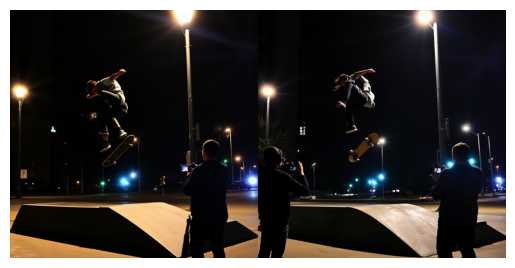

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


A giraffe and a zebra find themselves together at the bottom of a ditch. Describe their interaction, the environment around them, and how they might work together or react to their unusual situation. Consider their natural behaviors and possible ways they could escape or adapt to the ditch.
blury, low quality, unnatural


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

[0.026494357734918594, 0.3041897118091583]


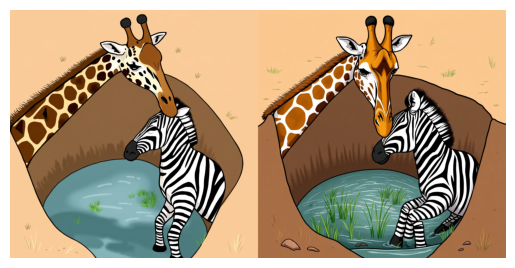

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


A female tennis player, wearing a blue outfit, stands poised on the court as she readies herself to strike the incoming tennis ball. Her focus is evident as she grips her racket, eyes locked on the ball, preparing for a powerful return in the midst of an intense match.
blury, low quality, unnatural


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

[1.150659203529358, 0.5203867554664612]


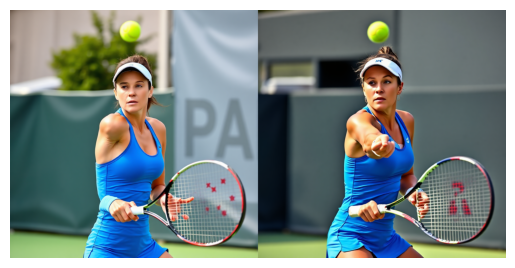

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


A stylish bedroom featuring a bed with an intricately designed, artistic headboard as the focal point. The room is complemented by a bold, striped carpet that adds visual interest and texture to the space. The overall ambiance is modern and creative, blending comfort with unique, eye-catching design elements throughout the room.
blury, low quality, unnatural


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

[1.7193318605422974, 1.7498725652694702]


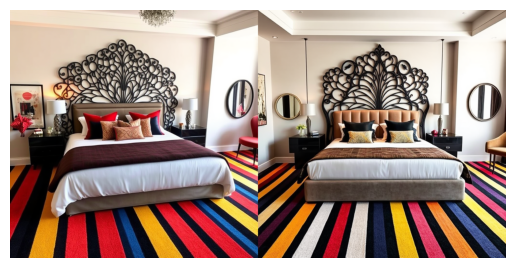

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


A horse-drawn cart carrying several passengers travels along a street beside an ornate Victorian-era building. The scene captures the charm of a bygone era, with the architecture’s intricate details and the cart’s rustic appearance evoking a sense of nostalgia and historical ambiance in the bustling city setting.
blury, low quality, unnatural


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

[1.5330820083618164, 1.2118242979049683]


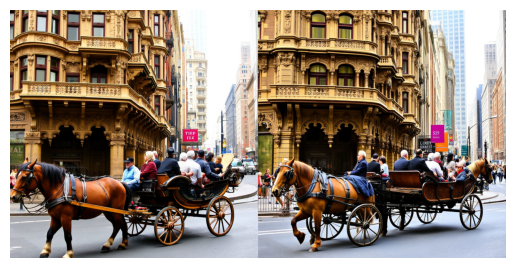

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Create an image featuring three distinct road signs, each one stacked vertically on top of the other. The signs should be clearly visible and easily distinguishable, with their shapes and symbols accurately depicted. The background should be a simple roadside setting to emphasize the arrangement of the stacked signs.
blury, low quality, unnatural


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

[0.42755693197250366, 0.5105627179145813]


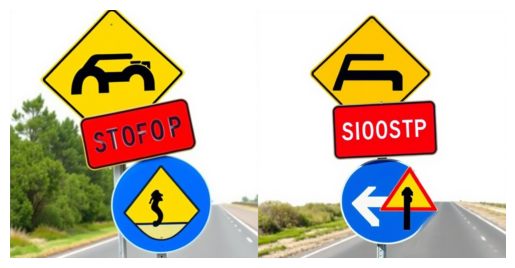

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


A small boat gently floats on the calm surface of a lake, positioned close to the shoreline. The water reflects the sky above, and the boat appears peaceful and still, creating a tranquil scene where nature and human presence quietly coexist near the edge of the water.
blury, low quality, unnatural


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

[-0.4619421660900116, -0.29671695828437805]


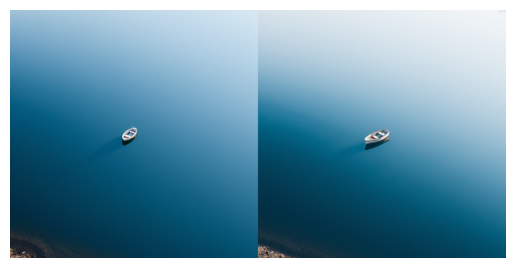

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


A tow truck is navigating a circular roundabout alongside a city bus. Both vehicles are moving in the same direction, sharing the curved roadway as they travel through the intersection. The scene takes place in an urban setting, highlighting the interaction between public transportation and service vehicles on city streets.
blury, low quality, unnatural


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

[1.3089487552642822, 1.292275071144104]


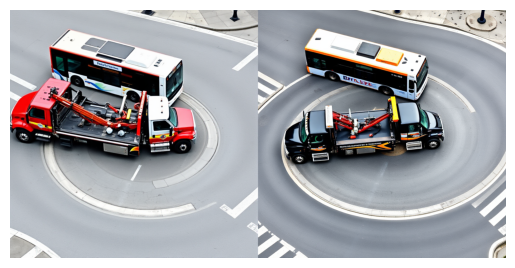

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Describe a unique bathroom design where a set of stairs leads up to the toilet. Consider the layout, materials, and possible reasons for this elevated placement. How does this affect the overall functionality and aesthetic of the space? Discuss any potential benefits or challenges this design might present.
blury, low quality, unnatural


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

[0.9446430206298828, 0.8970608115196228]


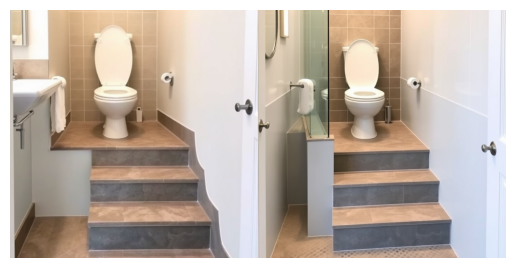

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Two zebras are peacefully grazing together on a lush, green field. The vibrant grass stretches around them, providing a serene and natural setting. Sunlight highlights their distinctive black and white stripes as they enjoy their meal, creating a picturesque scene of wildlife in their natural habitat, surrounded by open space.
blury, low quality, unnatural


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

[0.20493829250335693, 0.07937566936016083]


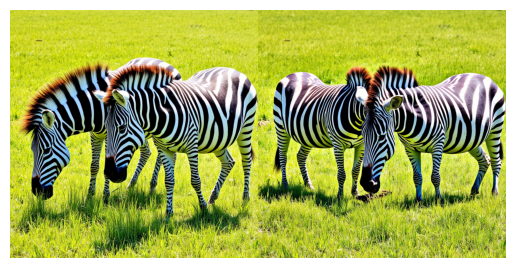

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


A group of individuals sits together around a dinner table, sharing a meal. The atmosphere is warm and inviting, with conversation and laughter filling the air as they enjoy each other's company and the delicious food before them, creating a memorable and convivial dining experience for everyone present.
blury, low quality, unnatural


  0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
import time
import numpy as np
import cv2
import random
seed = 10#random.randint(0, 10000)
print(seed)
win = 0
total = 0
wandb.init(project="flux")

# scores = np.zeros((2, 3))
ours_score = 0
vanilla_score = 0
prompts = ds["train"]["caption1"]
prompts = random.choices(prompts, k=500)

class Prompt(BaseModel):
  prompt: str

def rewrite(prompt):
    completion = client.beta.chat.completions.parse(
        model="gpt-4.1",
        messages=[
            {"role": "user", "content": [
                {"type": "text", "text": "Rewrite this prompt to 50 words: "+prompt},
            ]},
        ],
        response_format=Prompt,
        temperature=0.0,
    )
    return completion.choices[0].message.parsed.prompt

for i in prompts:
  positive_prompt = rewrite(i)

  negative_prompt = "blury, low quality, unnatural"#, poor detail, unnatural lighting, artifacts"
  # negative_prompt = i["neg"]# + "; low resolution, blury, low quality, poor details, unnatural lighting"
  NAGFluxPipeline._set_nag_attn_processor = get_set_function(len(pipe.tokenizer(positive_prompt).input_ids), len(pipe.tokenizer(negative_prompt).input_ids))
  print(positive_prompt)
  print(negative_prompt)
  image_ours = pipe(
      positive_prompt,
      guidance_scale=0.,
      nag_negative_prompt=negative_prompt,
      nag_scale=4,
      generator=torch.Generator(device="cuda").manual_seed(seed),
      num_inference_steps=2,
      max_sequence_length=256,
      nag_tau=2.5,
      nag_alpha=0.1
  ).images[0]


  NAGFluxPipeline._set_nag_attn_processor = _set_nag_attn_processor_vanilla

  image_vanilla = pipe(
      positive_prompt,
      guidance_scale=0.,
      nag_negative_prompt=negative_prompt,
      nag_scale=4,
      generator=torch.Generator(device="cuda").manual_seed(seed),
      num_inference_steps=2,
      max_sequence_length=256,
      nag_tau=2.5,
      nag_alpha=0.25,
  ).images[0]

  # ans = ask_gpxt(image_ours, image_vanilla, positive_prompt, negative_prompt).T
  # print(ans)
  # scores += ans
  scores = reward_model.score(positive_prompt, [image_ours, image_vanilla])
  print(scores)
  ours_score += scores[0]
  vanilla_score += scores[1]
  full = cv2.hconcat([np.array(image_ours), np.array(image_vanilla)])
  wandb.log({"img": wandb.Image(full, caption=f"+:{positive_prompt}\n-:{negative_prompt}"), "ours": ours_score, "vanilla": vanilla_score})
  pylab.imshow(full)
  pylab.axis('off')
  pylab.show()



In [ ]:
## compare is better score is not objective

In [ ]:
# import pandas as pd

# pd.DataFrame(scores, columns=["positive", "negative", "quality"], index=["ours", "vanilla"])